# Greeks via COS Method
COS computes Greeks through Fourier series derivatives. We validate against BS closed-form before moving to stochastic vol.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interactive

from cos_greeks import cos_greeks_full, bs_greeks_analytical, cos_price

## COS Greeks Formulas

From {cite:t}`FangOosterlee2008`, the COS option price is:

$$C = K e^{-rT} \sum_{k=0}^{N-1}\phantom{}' \text{Re}[H_k] V_k$$

where $H_k = \varphi\left(\frac{k\pi}{b-a}\right) e^{ik\pi\frac{x_0 - a}{b-a}}$ and $V_k$ are payoff coefficients.

**Delta** - differentiate w.r.t. $S_0$ (enters through $x_0 = \ln(S_0/K)$):

$$\Delta = -\frac{Ke^{-rT}}{S_0} \sum_{k=0}^{N-1}\phantom{}' \omega_k \, \text{Im}[H_k] V_k$$

where $\omega_k = \frac{k\pi}{b-a}$.

**Gamma** - second derivative:

$$\Gamma = \frac{Ke^{-rT}}{S_0^2} \sum_{k=0}^{N-1}\phantom{}' \left(\omega_k \, \text{Im}[H_k] - \omega_k^2 \, \text{Re}[H_k]\right) V_k$$

**Theta, Vega, Rho** - computed via finite differences. Analytical formulas exist but FD is simpler and accurate enough for validation.

## Point Comparison: COS vs Black-Scholes

ATM call, standard parameters.

In [2]:
# test params
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2

bs = bs_greeks_analytical(S0, K, T, r, sigma, 'call')
cos = cos_greeks_full(S0, K, T, r, sigma, model='bs', N=256, L=12, opt_type='call')

# build comparison table
greeks = ['price', 'delta', 'gamma', 'theta', 'vega', 'rho']
rows = []
for g in greeks:
    bs_val = bs[g]
    cos_val = cos[g]
    err = abs(cos_val - bs_val)
    rel_err = err / abs(bs_val) if abs(bs_val) > 1e-10 else err
    rows.append([g, bs_val, cos_val, err, rel_err])

df = pd.DataFrame(rows, columns=['Greek', 'BS Analytical', 'COS Method', 'Abs Error', 'Rel Error'])
df.set_index('Greek', inplace=True)
df.style.format({'BS Analytical': '{:.6f}', 'COS Method': '{:.6f}', 'Abs Error': '{:.2e}', 'Rel Error': '{:.2e}'})

,BS Analytical,COS Method,Abs Error,Rel Error
Greek,,,,
price,10.450584,10.450584,1.78e-15,1.70e-16
delta,0.636831,0.636831,1.54e-14,2.42e-14
gamma,0.018762,0.018762,1.08e-16,5.73e-15
theta,-6.414028,-6.415077,1.05e-03,1.64e-04
vega,37.524035,37.524034,3.04e-07,8.11e-09
rho,53.232482,53.232481,7.72e-07,1.45e-08


## Convergence Analysis

How does error decay as we increase the number of Fourier terms N?

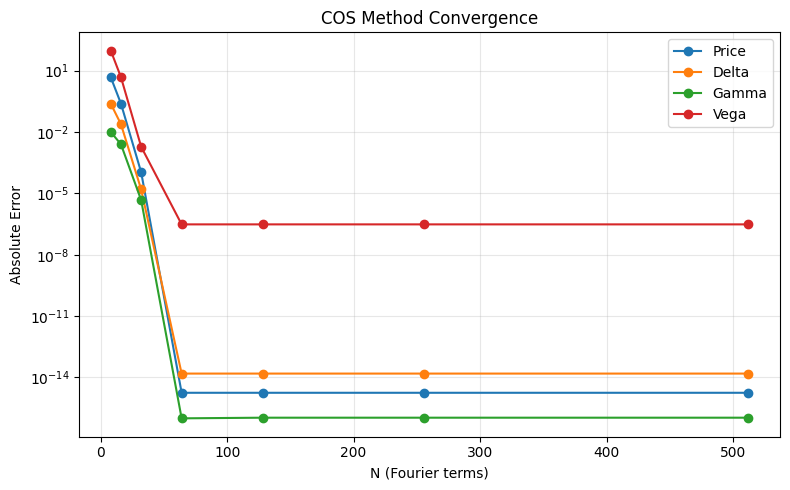

In [3]:
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.2
bs = bs_greeks_analytical(S0, K, T, r, sigma, 'call')

N_values = [8, 16, 32, 64, 128, 256, 512]
greeks_to_plot = ['price', 'delta', 'gamma', 'vega']

errors = {g: [] for g in greeks_to_plot}
for N in N_values:
    cos = cos_greeks_full(S0, K, T, r, sigma, model='bs', N=N, L=12, opt_type='call')
    for g in greeks_to_plot:
        err = abs(cos[g] - bs[g])
        errors[g].append(err if err > 1e-16 else 1e-16)  # floor for log scale

fig, ax = plt.subplots(figsize=(8, 5))
for g in greeks_to_plot:
    ax.semilogy(N_values, errors[g], 'o-', label=g.capitalize())

ax.set_xlabel('N (Fourier terms)')
ax.set_ylabel('Absolute Error')
ax.set_title('COS Method Convergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Greeks Across Strikes

Compare COS and BS Greeks for strikes from deep ITM to deep OTM.

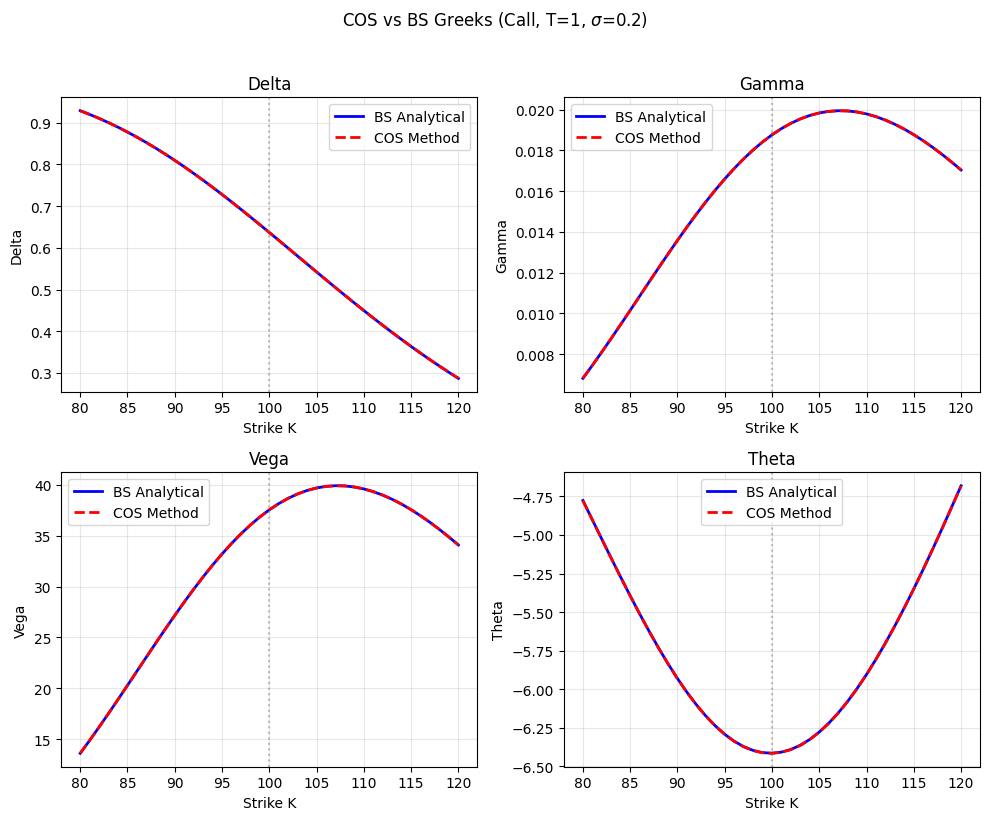

In [4]:
S0, T, r, sigma = 100, 1.0, 0.05, 0.2
K_range = np.linspace(80, 120, 41)

greeks_to_show = ['delta', 'gamma', 'vega', 'theta']
bs_vals = {g: [] for g in greeks_to_show}
cos_vals = {g: [] for g in greeks_to_show}

for K in K_range:
    bs = bs_greeks_analytical(S0, K, T, r, sigma, 'call')
    cos = cos_greeks_full(S0, K, T, r, sigma, model='bs', N=256, L=12, opt_type='call')
    for g in greeks_to_show:
        bs_vals[g].append(bs[g])
        cos_vals[g].append(cos[g])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, g in enumerate(greeks_to_show):
    ax = axes[idx]
    ax.plot(K_range, bs_vals[g], 'b-', lw=2, label='BS Analytical')
    ax.plot(K_range, cos_vals[g], 'r--', lw=2, label='COS Method')
    ax.axvline(S0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Strike K')
    ax.set_ylabel(g.capitalize())
    ax.set_title(g.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('COS vs BS Greeks (Call, T=1, $\\sigma$=0.2)', y=1.02)
plt.tight_layout()

## Interactive Comparison

Overlay COS and BS Greeks across spot prices. Check the match holds under different parameter regimes.

In [5]:
def compare_greeks(K=100, T=1.0, r=0.05, sigma=0.2, opt_type='call', greek='delta'):
    S_range = np.linspace(50, 150, 51)
    
    bs_values = []
    cos_values = []
    
    for S in S_range:
        bs = bs_greeks_analytical(S, K, T, r, sigma, opt_type)
        cos = cos_greeks_full(S, K, T, r, sigma, model='bs', N=256, L=12, opt_type=opt_type)
        bs_values.append(bs[greek])
        cos_values.append(cos[greek])
    
    bs_values = np.array(bs_values)
    cos_values = np.array(cos_values)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # left: overlay
    ax1.plot(S_range, bs_values, 'b-', lw=2, label='BS Analytical')
    ax1.plot(S_range, cos_values, 'r--', lw=2, label='COS Method')
    ax1.axvline(K, color='gray', linestyle=':', alpha=0.7, label=f'K={K}')
    ax1.set_xlabel('Spot Price S')
    ax1.set_ylabel(greek.capitalize())
    ax1.set_title(f'{greek.capitalize()} ({opt_type})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # right: error
    error = np.abs(cos_values - bs_values)
    ax2.semilogy(S_range, error + 1e-16, 'k-', lw=1.5)
    ax2.axvline(K, color='gray', linestyle=':', alpha=0.7)
    ax2.set_xlabel('Spot Price S')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title(f'{greek.capitalize()} Error')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # summary stats
    print(f"Max error: {error.max():.2e}, Mean error: {error.mean():.2e}")

interactive_plot = interactive(
    compare_greeks,
    K=widgets.FloatSlider(min=50, max=150, step=5, value=100, description='K'),
    T=widgets.FloatSlider(min=0.1, max=3, step=0.1, value=1.0, description='T'),
    r=widgets.FloatSlider(min=0, max=0.15, step=0.01, value=0.05, description='r'),
    sigma=widgets.FloatSlider(min=0.05, max=0.8, step=0.05, value=0.2, description='sigma'),
    opt_type=widgets.Dropdown(options=['call', 'put'], value='call', description='Type'),
    greek=widgets.Dropdown(options=['price', 'delta', 'gamma', 'theta', 'vega', 'rho'], 
                           value='delta', description='Greek')
)

display(interactive_plot)

interactive(children=(FloatSlider(value=100.0, description='K', max=150.0, min=50.0, step=5.0), FloatSlider(va…

COS matches BS Greeks to high precision (errors ~1e-6 for analytical, ~1e-4 for FD). Same code works for Heston or rough vol — just swap the characteristic function.